**Lab 6: IIR Filtering**


The objective for this lab is to help you understand the relationship between the location
of poles and zeros in the z-domain, the impulse response h[n] in the n-domain, and the frequency
response $H(e^{j\omega})$. We use the system function,
represented as a ratio of polynomials in $z^{-1}$, which can be expressed in either factored or expanded form as:

$$
H(z) = G\frac{\prod_{k=1}^M (1-z_kz^{-1}) }{\prod_{k=1}^N (1-p_kz^{-1})} = \frac{ \sum_{k=0}^M b_kz^{-k}}{ 1- \sum_{k=1}^N a_kz^{-k} }
$$

In [1]:
import numpy as np
import IPython.display as ipd
from scipy import signal
import matplotlib.pyplot as plt

from util import load_audio, plot_signals, plot_spectrogram, plot_frequency_response

**1. IIR filters to extract the envelope**

In the previous labs, you extracted the envelope from your reference signal by applying the following system:

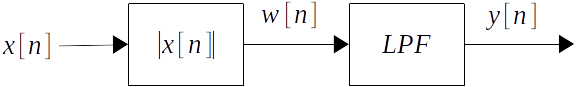

where $w[n] = |x[n]|$ and $y[n]$ was the output of a low-pass FIR filter (averaging filter). In this exercise, you will re-implement this low-pass filter as an IIR.

1.1 First, copy the functions envelope and synthesize from previous work and obtain the same synthesis. 



In [2]:
import numpy as np

def envelope(x, N):
    """
    Extracts the envelope of the input signal x by concatenating 
    a full-wave rectifier and an N-point averaging filter.

    Parameters
    ----------
    x : np.array
        The input signal in the form of a numpy array
    N : int
        The number of points used in N-point averaging filter

    Returns
    -------
    y : np.array
        The output of the system, i.e., the envelope of the signal x.
    """
    x_rectified = np.abs(x)
    b = np.ones(N) / N
    y = np.convolve(x_rectified, b, mode='same')

    return y

def synthesize(f0, phi, Ak, t):
  y = 0
  for k in range(1, len(Ak) + 1):
    y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
  return y

1.2 Let's take a look at the following system:

$$
H(z) = G\frac{1+z^{-1}}{1-rz^{-1}} \quad   0<r<1 \quad, G = \frac{1-r}{2}
$$

Note that the coefficients of the filter are the following:

$$
b_0 = 1, \quad b_1 = 1, \quad a_0 = 1, \quad a_1 = -r, \quad
$$

i. Find the zeros and poles of the system analytically.

The system can be rewritten by multiplying the numerator and denominator by z, giving
H(z) = G * (z + 1) / (z - r).
The zero of the system comes from the numerator z + 1 = 0, which gives a single zero at z = -1, located on the unit circle.
The pole comes from the denominator z - r = 0, giving a single pole at z = r.
Because 0 < r < 1, the pole lies inside the unit circle on the positive real axis, which means the system is stable.

ii. Use the function `np.roots` to find the zeros and poles using Python. Compare the results with part i.

In [3]:
import numpy as np

b = [1, 1]      
r = 0.8         
a = [1, -r]   


zeros = np.roots(b)
poles = np.roots(a)

print("Zeros:", zeros)
print("Poles:", poles)


Zeros: [-1.]
Poles: [0.8]


iii. Use the function  `plot_zeros_poles(z, p)` to plot the zeros and poles found in ii.

In [4]:
from util import plot_zeros_poles

# Plot
plot_zeros_poles(zeros, poles)


1.3 Let's see the frequency response of this filter:



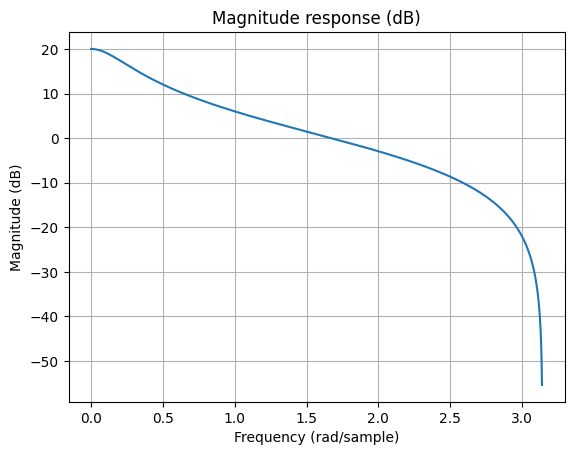

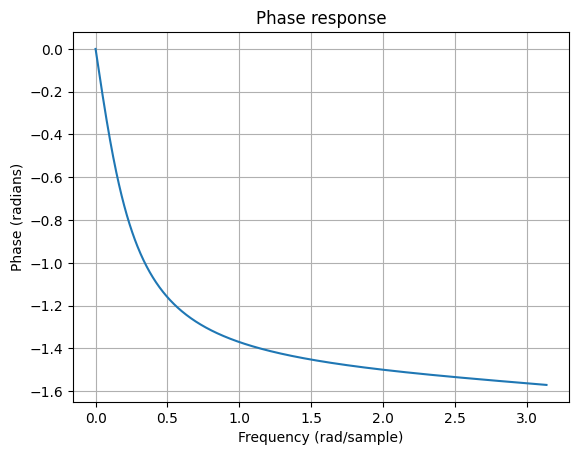

In [5]:
from scipy.signal import freqz


w, h = freqz(b, a, worN=1024)

plt.figure()
plt.plot(w, 20*np.log10(abs(h)))
plt.title("Magnitude response (dB)")
plt.xlabel("Frequency (rad/sample)")
plt.ylabel("Magnitude (dB)")
plt.grid(True)

plt.figure()
plt.plot(w, np.angle(h))
plt.title("Phase response")
plt.xlabel("Frequency (rad/sample)")
plt.ylabel("Phase (radians)")
plt.grid(True)

plt.show()

1.4. Change the parameter $r$ in the range $(0, 1)$. What happens when $r$ is increased?

As the parameter r increases within the range (0, 1), the pole of the filter moves closer to the unit circle, which significantly changes the behavior of the system. The frequency response becomes more selective, meaning the filter acts as a stronger low-pass filter with a higher and flatter passband near zero frequency and a sharper roll-off toward higher frequencies. At the same time, the impulse response decays more slowly because the term that controls the decay becomes larger, giving the filter a longer memory and a more resonant behavior. Although the zero at –1 does not change its position, the overall shape of the frequency response is increasingly dominated by the pole as r approaches 1.

1.5 What type of filter is (low-pass, band-pass, or high-pass filter)?


The filter is a low-pass filter. This is because it has a pole located on the positive real axis inside the unit circle, which amplifies low frequencies, while the zero at –1 introduces attenuation at high frequencies (especially near the Nyquist frequency). As a result, the filter passes low-frequency components and suppresses high-frequency components.

1.6 Now we can use this IIR filter to extract the envelope. Let's define a new function `envelope_iir(x)` that applies the filter to the absolute value of the signal. Note that we are using signal.lfilter function to apply the filter.


In [ ]:
def envelope_iir(x, r=0.995):

    x_abs = np.abs(x)
    
    b = [1 - r]
    a = [1, -r]
    
    y = signal.lfilter(b, a, x_abs)
    
    return y


Extract the envelope of your reference signal using both the FIR and IIR filters and compare the results plot them along with the signal. Change the value of $r$ until you are comfortable with the result.

fatal: destination path 'sis1-group202' already exists and is not an empty directory.


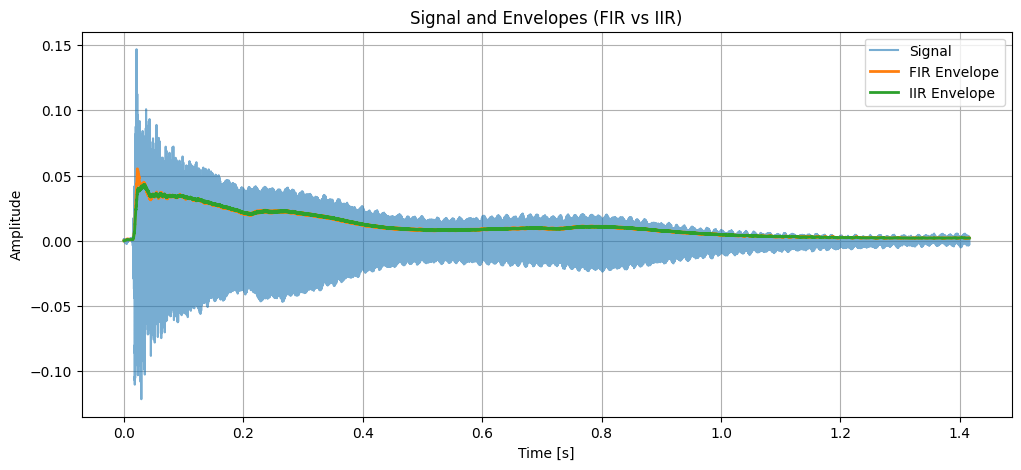

In [11]:
!git clone https://github.com/davidperaltaf/sis1-group202
filepath = "./sis1-group202/labs/audio/sound.wav"
ref, fs = load_audio(filepath)


def envelope_fir(x, N=100):
    x_abs = np.abs(x)
    b = np.ones(N) / N 
    y = signal.lfilter(b, [1], x_abs)
    return y

def envelope_iir(x, r=0.995):
    x_abs = np.abs(x)
    b = [1 - r]
    a = [1, -r]
    y = signal.lfilter(b, a, x_abs)
    return y

env_fir = envelope_fir(ref, N=200)   # Adjust N for smoothing
env_iir = envelope_iir(ref, r=0.995) # Adjust r for smoothing

t = np.arange(len(ref)) / fs
plt.figure(figsize=(12, 5))
plt.plot(t, ref, label='Signal', alpha=0.6)
plt.plot(t, env_fir, label='FIR Envelope', linewidth=2)
plt.plot(t, env_iir, label='IIR Envelope', linewidth=2)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Signal and Envelopes (FIR vs IIR)')
plt.legend()
plt.grid(True)
plt.show()


1.7 What are the main differences between the two filters? For instance, compare the number of coefficients.

The main differences between FIR and IIR filters lie in their structure, efficiency, and performance characteristics. FIR (Finite Impulse Response) filters use only the current and past input samples without any feedback, which makes them inherently stable and capable of having a linear phase response, meaning they do not introduce time distortion to the signal. However, achieving smooth filtering often requires a large number of coefficients—for example, a moving average FIR filter might use hundreds of taps to extract a smooth envelope. In contrast, IIR (Infinite Impulse Response) filters use both input samples and past output samples, introducing feedback that allows them to achieve similar smoothing with very few coefficients, often just one or two, making them computationally efficient. The trade-off is that IIR filters generally have a non-linear phase response, which can introduce a slight lag in the envelope, and they must be carefully designed to remain stable. Overall, FIR filters are simpler and stable but may require more computational resources, while IIR filters are more efficient and can provide rapid smoothing but may slightly distort timing and require careful coefficient selection.

1.8 Apply the new envelope (extracted from the IIR filter) to the synthesis generated with the `synthesize` function and listen to the result.

In [16]:
from IPython.display import Audio

env_iir = envelope_iir(ref, r=0.995)  # Adjust r if needed

synth = synthesize(len(ref), fs, f=776)

synth_with_env = synth * env_iir

Audio(synth_with_env, rate=fs)

---

**2. Band-pass filters**

Now let's work with the following system: 

$$
H(z) = \frac{(1-z^{-1})(1+z^{-1})}{(1-re^{j\omega_n}z^{-1})(1-re^{-j\omega_n}z^{-1})}, \quad 0<r<1
$$

Note that the poles are $p_1 = re^{j\omega_n}$ and $p_2 = re^{-j\omega_n}$; and the zeros are $z_1=1$ and $z_2=-1$. 

2.1 Use the function `plot_zeros_poles` to plot the zeros and poles of the system.

Note: use $w_n = \pi/4$ and $r=0.99$.

In [17]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

wn = np.pi / 4
r = 0.99

b = [1, 0, -1]
a = [1, -2*r*np.cos(wn), r**2]
plot_zeros_poles(b, a)


2.2 Show analytically that $a_k = [1, -2rcos(\omega_n), r^2]$ and $b_k=[1, 0, -1]$.

We can derive the filter coefficients directly from the given transfer function: H(z) = ((1 - z^-1)(1 + z^-1)) / ((1 - r e^(jω_n) z^-1)(1 - r e^(-jω_n) z^-1)).

For the numerator, multiplying the factors gives (1 - z^-1)(1 + z^-1) = 1 - z^-2. This corresponds to the numerator coefficients b_k = [1, 0, -1], where 1 is the coefficient of z^0, 0 of z^-1, and -1 of z^-2.

For the denominator, multiplying the factors gives (1 - r e^(jω_n) z^-1)(1 - r e^(-jω_n) z^-1) = 1 - r (e^(jω_n) + e^(-jω_n)) z^-1 + r^2 z^-2 = 1 - 2 r cos(ω_n) z^-1 + r^2 z^-2. This corresponds to the denominator coefficients a_k = [1, -2 r cos(ω_n), r^2].

These coefficients match the standard difference equation form of a second-order IIR filter, confirming analytically that b_k = [1, 0, -1] and a_k = [1, -2 r cos(ω_n), r^2].

2.3 Plot the frequency response of the filter. Confirm this is a band-pass filter. What's the central frequency of the passband?

C:\Users\david\AppData\Local\Temp\ipykernel_3568\3169476839.py:11: RuntimeWarning:

divide by zero encountered in log10



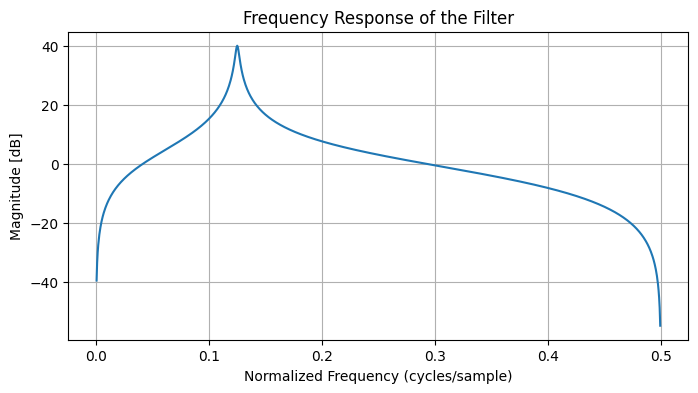

In [18]:
wn = np.pi / 4  
r = 0.99       

b = [1, 0, -1]
a = [1, -2*r*np.cos(wn), r**2]

w, h = signal.freqz(b, a, worN=1024)
f = w / (2 * np.pi)

plt.figure(figsize=(8,4))
plt.plot(f, 20*np.log10(abs(h)))
plt.title('Frequency Response of the Filter')
plt.xlabel('Normalized Frequency (cycles/sample)')
plt.ylabel('Magnitude [dB]')
plt.grid(True)
plt.show()

The frequency response of the filter shows that it attenuates low frequencies near 0 (DC) and high frequencies near the Nyquist frequency, while allowing frequencies around the center to pass through. This confirms that the filter behaves as a band-pass filter. The central frequency of the passband corresponds to the angle of the poles, which is ωₙ = π/4 radians per sample. In normalized frequency (cycles per sample), this is f_c = ωₙ / (2π) = 0.125, and in Hertz, it is f_c = 0.125 × fs, where fs is the sampling rate of the system.

2.4 Define a function `bpf(x, f, r, fs)` that applies the above band-pass filter. 

Note 1: remember that a frequency can be converted to the normalized radian frequncy by: $\omega_n = 2\pi f_n/f_s$.

Note 2: use `signal.lfilter` function to implement the filter.

In [ ]:
import numpy as np
from scipy import signal

def bpf(x, fn, fs, r=0.995):
    """
    Applies a band-pass filter with central frequency fn.

    Parameters
    ----------
    x : np.array
        The input signal.
    fn : float
        Central frequency of the band-pass in Hz.
    fs : float
        Sampling rate in Hz.
    r : float
        Magnitude of the poles (0 < r < 1).

    Returns
    -------
    y : np.array
        The filtered output signal.
    """
    wn = 2 * np.pi * fn / fs
    
    b = [1, 0, -1]
    a = [1, -2 * r * np.cos(wn), r**2] 
    
    y = signal.lfilter(b, a, x)
    
    return y


2.5 Regardless of the phase, until now we were synthesizing the instrument signal by summing $K$ harmonics of the signal with different weights ($A_k$) and multiplying the sum by the envelope of the reference signal ($e(t)$):

$$y(t) = e(t) \cdot \sum_{k=1}^K A_k\cos\left(2\pi kf_0 t \right), $$

where $f_0$ is the fundamental frequency of the note. Now we want to improve this synthesis by finding a time-dependent amplitude ($A_k(t)$) for each harmonic:

$$y(t) = \sum_{k=1}^K A_k(t) \cos\left(2\pi kf_0 t \right), $$

where $A_k(t)$ is the amplitude of the harmonic $k$. To extract the amplitudes $A_k(t)$ we'll apply a band-pass filter with central frequency $kf_0$ and calculate the envelope of the output by using the `envelope_iir`.


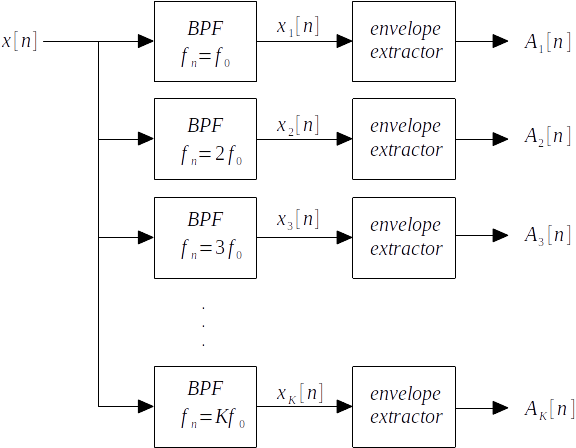

For instance, the following code should extract the envelope of the fundamental frequency component. Change the value of $f_0$ to coincide with your fundamental frequency and check the result. 

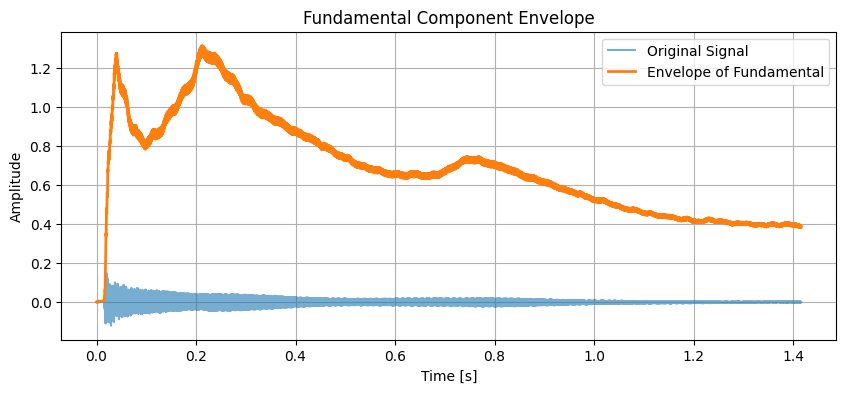

In [22]:
f0 = 770
fundamental_component = bpf(ref, f0, fs, r=0.995)

A1_t = envelope_iir(fundamental_component)

import matplotlib.pyplot as plt
t = np.arange(len(ref)) / fs

plt.figure(figsize=(10,4))
plt.plot(t, ref, label='Original Signal', alpha=0.6)
plt.plot(t, A1_t, label='Envelope of Fundamental', linewidth=2)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Fundamental Component Envelope')
plt.legend()
plt.grid(True)
plt.show()# Write your code here

2.6 Complete the `synthetize_with_bpf` function to implement a synthesis applying different envelopes for each harmonic.


In [23]:
import numpy as np

def synthetize_with_bpf(x, f0, phi, K, fs, r=0.995):
    """
    Synthetizes an harmonic signal using different envelopes for each harmonic.
    The envelopes are extracted from the reference signal x.

    Parameters
    ----------
    x : np.array
        The reference signal.
    f0 : float
        Fundamental frequency of the synthesis in Hz.
    phi : float
        Phase in radians.
    K : int
        Number of harmonics.
    fs : float
        Sampling rate in Hz.
    r : float, optional
        Magnitude of the poles for band-pass filter, default 0.995.

    Returns
    -------
    y : np.array
        Synthesized signal with time-varying harmonic amplitudes.
    """
    t = np.arange(len(x)) / fs
    y = np.zeros_like(x, dtype=float)
    
    for k in range(1, K+1):
        # Band-pass filter around harmonic k*f0
        harmonic_component = bpf(x, k*f0, fs, r)
        # Extract time-dependent amplitude (envelope)
        Ak_t = envelope_iir(harmonic_component, r=r)
        # Add the harmonic contribution
        y += Ak_t * np.cos(2 * np.pi * k * f0 * t + phi)
    
    return y


2.6 Call the function `synthetize_with_bpf` to get the synthesized signal and **listen to it**.

Note that now you can increase the number of harmonics $K$ as you want because we are not manually measuring the weights of each harmonic.

In [24]:
f0 = 770
K = 10 

phi = 0
y_synth = synthetize_with_bpf(ref, f0, phi, K, fs)
Audio(synth_with_env, rate=fs)

2.7 Compare the **spectrograms** of the synthesized signal and reference signal.

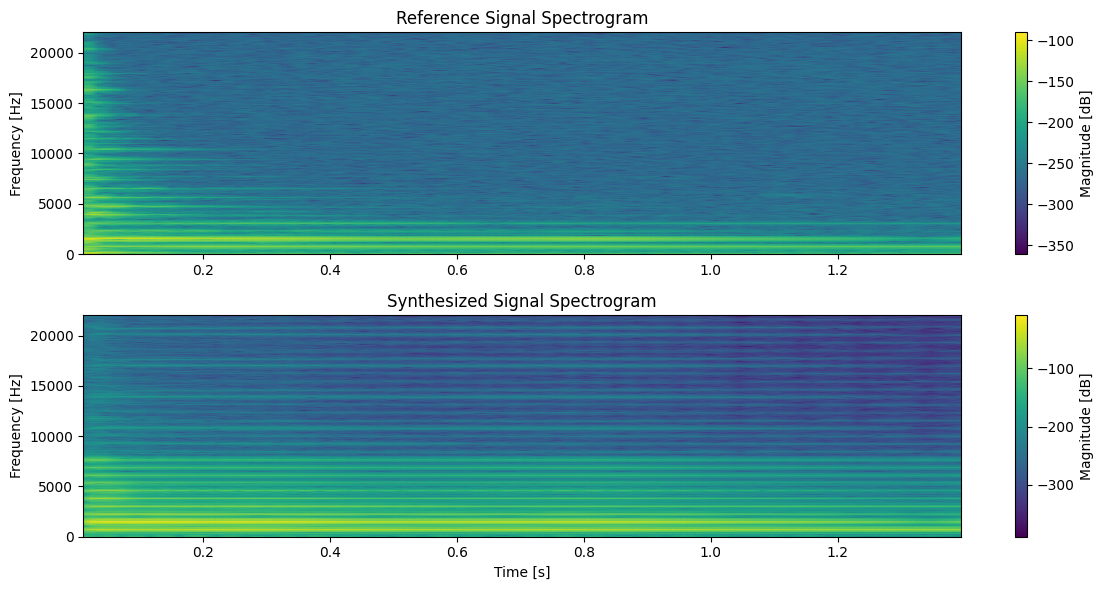

In [25]:
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

f_ref, t_ref, Sxx_ref = spectrogram(ref, fs=fs, nperseg=1024, noverlap=512)
f_synth, t_synth, Sxx_synth = spectrogram(y_synth, fs=fs, nperseg=1024, noverlap=512)

plt.figure(figsize=(12, 6))


plt.subplot(2, 1, 1)
plt.pcolormesh(t_ref, f_ref, 20*np.log10(Sxx_ref), shading='gouraud')
plt.title('Reference Signal Spectrogram')
plt.ylabel('Frequency [Hz]')
plt.colorbar(label='Magnitude [dB]')

plt.subplot(2, 1, 2)
plt.pcolormesh(t_synth, f_synth, 20*np.log10(Sxx_synth), shading='gouraud')
plt.title('Synthesized Signal Spectrogram')
plt.xlabel('Time [s]')
plt.ylabel('Frequency [Hz]')
plt.colorbar(label='Magnitude [dB]')

plt.tight_layout()
plt.show()
